1. cài đặt thư viện

In [ ]:
!pip install -q -U \
    "transformers>=4.57,<5" \
    "trl==0.29.0" \
    "peft>=0.17,<1" \
    "accelerate>=1.10,<2" \
    "bitsandbytes>=0.47,<1" \
    "datasets>=4.1,<5" \
    sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


2. Kết nối Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import torch
import platform

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA khả dụng:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "Chưa có GPU. Hãy chọn "
        "Runtime → Change runtime type → T4 GPU."
    )

gpu_name = torch.cuda.get_device_name(0)

gpu_memory = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)

print("GPU:", gpu_name)
print("VRAM:", round(gpu_memory, 2), "GB")

!nvidia-smi

Mounted at /content/drive
Python: 3.13.15
PyTorch: 2.11.0+cu130
CUDA khả dụng: True
GPU: Tesla T4
VRAM: 14.56 GB
Fri Oct  9 11:16:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                          

3. cấu hình

In [ ]:
from pathlib import Path

# ============================================================
# ĐƯỜNG DẪN DỰ ÁN
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ViGovBot_KLCN_2026"
)

DATA_ROOT = PROJECT_DIR / "data"

TEST_CASE_DIR = (
    DATA_ROOT
    / "qa_test"
    / "tthc_test_case_v1"
)

FINETUNING_DATA_DIR = (
    TEST_CASE_DIR
    / "data"
    / "fintuning"
)


# ============================================================
# BA TẬP DỮ LIỆU
# ============================================================

TRAIN_FILE = (
    FINETUNING_DATA_DIR
    / "train_sft.jsonl"
)

VALIDATION_FILE = (
    FINETUNING_DATA_DIR
    / "validation_sft.jsonl"
)

TEST_FILE = (
    FINETUNING_DATA_DIR
    / "test_sft.jsonl"
)


# ============================================================
# THƯ MỤC LƯU KẾT QUẢ
# ============================================================

OUTPUT_ROOT = (
    TEST_CASE_DIR
    / "results"
    / "qwen2_5_7b_qlora"
)

ADAPTER_DIR = OUTPUT_ROOT / "adapter"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
EVALUATION_DIR = OUTPUT_ROOT / "evaluation"
FIGURES_DIR = OUTPUT_ROOT / "figures"

for directory in [
    OUTPUT_ROOT,
    ADAPTER_DIR,
    CHECKPOINT_DIR,
    EVALUATION_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# CẤU HÌNH MÔ HÌNH
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_REVISION = "main"

SEED = 42
MAX_LENGTH = 1024
NUM_EPOCHS = 1

print("===== CẤU HÌNH THỰC NGHIỆM =====")
print("Dữ liệu:", FINETUNING_DATA_DIR)
print("Train:", TRAIN_FILE)
print("Validation:", VALIDATION_FILE)
print("Test:", TEST_FILE)
print("Kết quả:", OUTPUT_ROOT)
print("Adapter:", ADAPTER_DIR)

===== CẤU HÌNH THỰC NGHIỆM =====
Dữ liệu: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning
Train: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/train_sft.jsonl
Validation: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/validation_sft.jsonl
Test: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/test_sft.jsonl
Kết quả: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora
Adapter: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/adapter


4. kiểm tra

In [ ]:
required_files = {
    "Train": TRAIN_FILE,
    "Validation": VALIDATION_FILE,
    "Test": TEST_FILE,
}

print("===== KIỂM TRA FILE DỮ LIỆU =====")

for split_name, file_path in required_files.items():
    print(f"\n{split_name}:")
    print(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy file {split_name}: {file_path}"
        )

    file_size_mb = (
        file_path.stat().st_size
        / 1024**2
    )

    print("Trạng thái: Đã tìm thấy")
    print(f"Kích thước: {file_size_mb:.2f} MB")

print("\nĐã tìm thấy đầy đủ ba tập dữ liệu.")

===== KIỂM TRA FILE DỮ LIỆU =====

Train:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/train_sft.jsonl
Trạng thái: Đã tìm thấy
Kích thước: 3.22 MB

Validation:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/validation_sft.jsonl
Trạng thái: Đã tìm thấy
Kích thước: 1.06 MB

Test:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/test_sft.jsonl
Trạng thái: Đã tìm thấy
Kích thước: 1.06 MB

Đã tìm thấy đầy đủ ba tập dữ liệu.


5. Đọc dữ liệu pilot

In [ ]:
from datasets import (
    DatasetDict,
    load_dataset,
)


def load_sft_split(
    file_path,
    split_name,
):
    dataset = load_dataset(
        "json",
        data_files=str(file_path),
        split="train",
    )

    required_columns = {
        "id",
        "messages",
    }

    missing_columns = (
        required_columns
        - set(dataset.column_names)
    )

    if missing_columns:
        raise ValueError(
            f"{split_name} thiếu các cột: "
            f"{sorted(missing_columns)}"
        )

    # Chỉ giữ các trường cần dùng
    extra_columns = [
        column
        for column in dataset.column_names
        if column not in required_columns
    ]

    if extra_columns:
        dataset = dataset.remove_columns(
            extra_columns
        )

    print(f"\n{split_name}:")
    print("- Số mẫu:", len(dataset))
    print("- Các cột:", dataset.column_names)

    return dataset


train_raw = load_sft_split(
    TRAIN_FILE,
    "Train",
)

validation_raw = load_sft_split(
    VALIDATION_FILE,
    "Validation",
)

test_raw = load_sft_split(
    TEST_FILE,
    "Test",
)


raw_datasets = DatasetDict({
    "train": train_raw,
    "validation": validation_raw,
    "test": test_raw,
})


print("\n===== DATASET SAU KHI ĐỌC =====")
print(raw_datasets)

print("\nMột mẫu Train:")
print(raw_datasets["train"][0])

print("\nMột mẫu Test:")
print(raw_datasets["test"][0])

Generating train split: 0 examples [00:00, ? examples/s]


Train:
- Số mẫu: 3000
- Các cột: ['id', 'messages']


Generating train split: 0 examples [00:00, ? examples/s]


Validation:
- Số mẫu: 1000
- Các cột: ['id', 'messages']


Generating train split: 0 examples [00:00, ? examples/s]


Test:
- Số mẫu: 1000
- Các cột: ['id', 'messages']

===== DATASET SAU KHI ĐỌC =====
DatasetDict({
    train: Dataset({
        features: ['id', 'messages'],
        num_rows: 3000
    })
    validation: Dataset({
        features: ['id', 'messages'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['id', 'messages'],
        num_rows: 1000
    })
})

Một mẫu Train:
{'id': 'qa2_00001', 'messages': [{'role': 'user', 'content': 'Bạn ơi, đối với “Phê duyệt Báo cáo phân tích an toàn trong xây dựng cơ sở bức xạ” (mã 1.014658), phí, lệ phí khi nộp bằng hình thức Trực tuyến được ghi thế nào? Giải thích giúp mình với.'}, {'role': 'assistant', 'content': 'Phí, lệ phí (khi nộp bằng hình thức Trực tuyến): 25.000.000 VNĐ, 40.000.000 VNĐ, 15.000.000 VNĐ'}]}

Một mẫu Test:
{'id': 'qa2_00007', 'messages': [{'role': 'user', 'content': 'Đối với “Cấp Chứng chỉ nhân viên bức xạ (trừ người phụ trách an toàn cơ sở sử dụng thiết bị X-quang chẩn đoán y tế, thiết bị chụp cắt lớp vi tính tí

6. Kiểm tra cấu trúc dữ liệu

In [ ]:
import json


def validate_sft_example(example):
    example_id = example.get("id")
    messages = example.get("messages")

    if not isinstance(example_id, str):
        return False

    if not example_id.strip():
        return False

    if not isinstance(messages, list):
        return False

    # Mỗi cuộc hội thoại phải có số message chẵn:
    # user → assistant hoặc
    # user → assistant → user → assistant
    if len(messages) < 2:
        return False

    if len(messages) % 2 != 0:
        return False

    expected_roles = (
        ["user", "assistant"]
        * (len(messages) // 2)
    )

    actual_roles = []

    for message in messages:
        if not isinstance(message, dict):
            return False

        role = message.get("role")
        content = message.get("content")

        if role not in {
            "user",
            "assistant",
        }:
            return False

        if not isinstance(content, str):
            return False

        if not content.strip():
            return False

        actual_roles.append(role)

    if actual_roles != expected_roles:
        return False

    return True


# ============================================================
# KIỂM TRA TỪNG SPLIT
# ============================================================

for split_name in [
    "train",
    "validation",
    "test",
]:
    invalid_ids = [
        example.get("id", "unknown")
        for example in raw_datasets[split_name]
        if not validate_sft_example(example)
    ]

    print(
        f"{split_name}: "
        f"{len(invalid_ids)} mẫu không hợp lệ"
    )

    if invalid_ids:
        print("Một số ID lỗi:", invalid_ids[:10])

        raise ValueError(
            f"Tập {split_name} có dữ liệu không hợp lệ."
        )


# ============================================================
# KIỂM TRA ID TRÙNG TRONG TỪNG SPLIT
# ============================================================

split_ids = {}

for split_name in [
    "train",
    "validation",
    "test",
]:
    ids = [
        example["id"]
        for example in raw_datasets[split_name]
    ]

    split_ids[split_name] = set(ids)

    if len(ids) != len(set(ids)):
        raise ValueError(
            f"Tập {split_name} có ID bị trùng."
        )


# ============================================================
# KIỂM TRA ID GIỮA CÁC SPLIT
# ============================================================

train_validation_overlap = (
    split_ids["train"]
    & split_ids["validation"]
)

train_test_overlap = (
    split_ids["train"]
    & split_ids["test"]
)

validation_test_overlap = (
    split_ids["validation"]
    & split_ids["test"]
)

print("\n===== KIỂM TRA ID GIAO NHAU =====")
print(
    "Train ∩ Validation:",
    len(train_validation_overlap),
)
print(
    "Train ∩ Test:",
    len(train_test_overlap),
)
print(
    "Validation ∩ Test:",
    len(validation_test_overlap),
)

if (
    train_validation_overlap
    or train_test_overlap
    or validation_test_overlap
):
    raise ValueError(
        "ID giữa các tập dữ liệu đang bị trùng."
    )


# ============================================================
# KIỂM TRA PROMPT TRÙNG HOÀN TOÀN
# ============================================================

def prompt_signature(example):
    # Không đưa đáp án assistant cuối cùng vào prompt
    prompt_messages = example["messages"][:-1]

    return json.dumps(
        prompt_messages,
        ensure_ascii=False,
        sort_keys=True,
    )


prompt_sets = {}

for split_name in [
    "train",
    "validation",
    "test",
]:
    prompt_sets[split_name] = {
        prompt_signature(example)
        for example in raw_datasets[split_name]
    }


print("\n===== KIỂM TRA PROMPT TRÙNG =====")

print(
    "Train ∩ Validation:",
    len(
        prompt_sets["train"]
        & prompt_sets["validation"]
    ),
)

print(
    "Train ∩ Test:",
    len(
        prompt_sets["train"]
        & prompt_sets["test"]
    ),
)

print(
    "Validation ∩ Test:",
    len(
        prompt_sets["validation"]
        & prompt_sets["test"]
    ),
)

print("\nToàn bộ dữ liệu hợp lệ.")

train: 0 mẫu không hợp lệ
validation: 0 mẫu không hợp lệ
test: 0 mẫu không hợp lệ

===== KIỂM TRA ID GIAO NHAU =====
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

===== KIỂM TRA PROMPT TRÙNG =====
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Toàn bộ dữ liệu hợp lệ.


6A. vẽ biểu đồ train


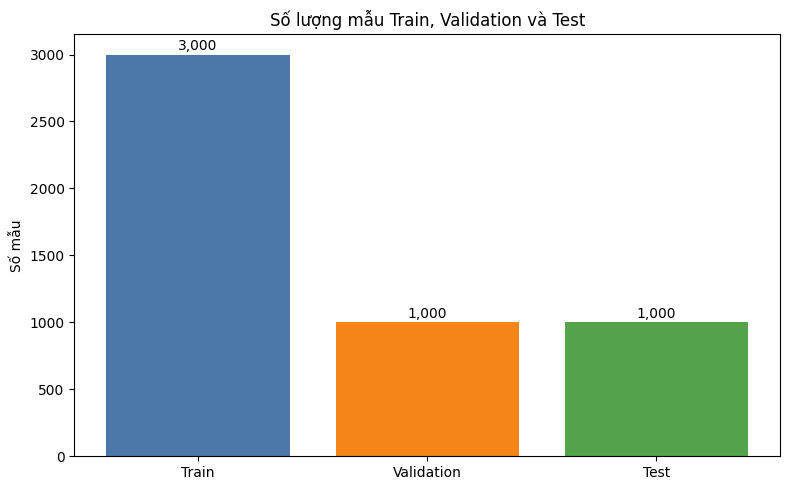

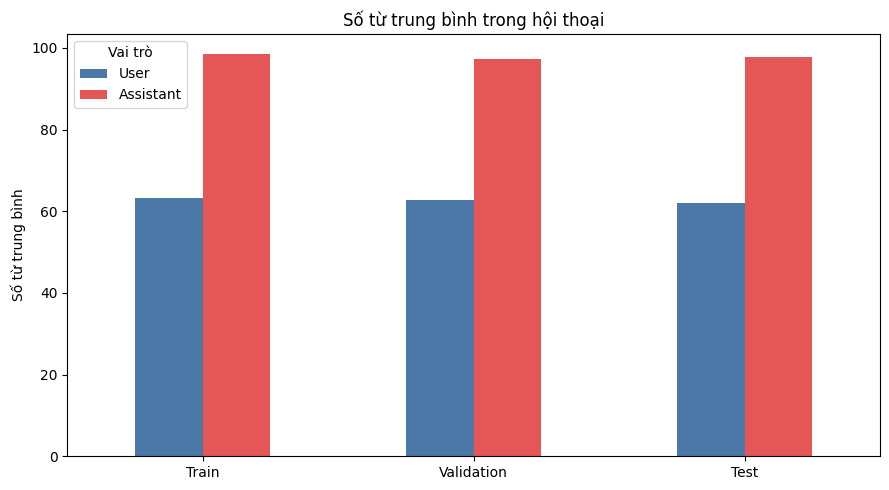

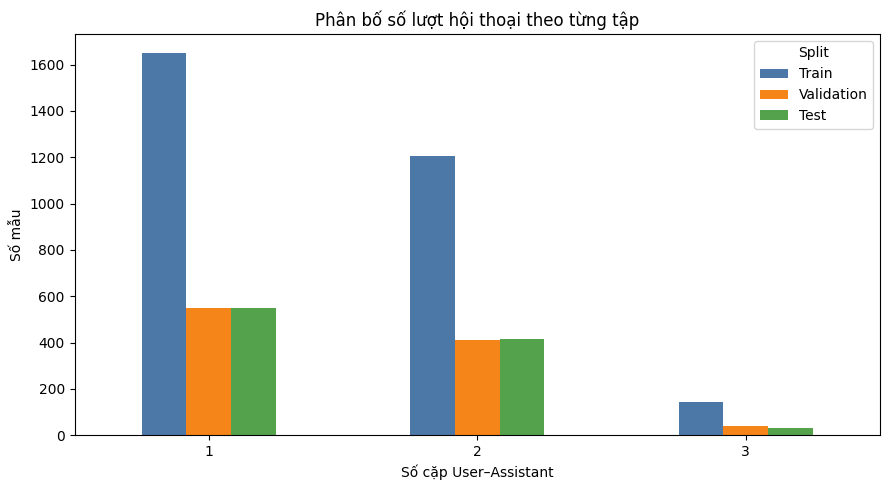

Đã lưu ba biểu đồ tại:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures


In [ ]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# HÀM THỐNG KÊ
# ============================================================

def count_words_by_role(
    example,
    target_role,
):
    contents = [
        message["content"]
        for message in example["messages"]
        if message["role"] == target_role
    ]

    return sum(
        len(content.split())
        for content in contents
    )


split_names = [
    "train",
    "validation",
    "test",
]

display_names = [
    "Train",
    "Validation",
    "Test",
]

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
]


# ============================================================
# BIỂU ĐỒ 1: SỐ LƯỢNG MẪU
# ============================================================

sample_counts = [
    len(raw_datasets[split_name])
    for split_name in split_names
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    display_names,
    sample_counts,
    color=colors,
)

for bar, value in zip(
    bars,
    sample_counts,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 30,
        f"{value:,}",
        ha="center",
    )

plt.title(
    "Số lượng mẫu Train, Validation và Test"
)
plt.ylabel("Số mẫu")
plt.tight_layout()

split_count_chart = (
    FIGURES_DIR
    / "01_split_sample_counts.png"
)

plt.savefig(
    split_count_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# BIỂU ĐỒ 2: ĐỘ DÀI TRUNG BÌNH
# ============================================================

length_rows = []

for split_name, display_name in zip(
    split_names,
    display_names,
):
    dataset = raw_datasets[split_name]

    user_words = [
        count_words_by_role(
            example,
            "user",
        )
        for example in dataset
    ]

    assistant_words = [
        count_words_by_role(
            example,
            "assistant",
        )
        for example in dataset
    ]

    length_rows.append({
        "Split": display_name,
        "User": sum(user_words) / len(user_words),
        "Assistant": (
            sum(assistant_words)
            / len(assistant_words)
        ),
    })


length_df = pd.DataFrame(length_rows)
length_df = length_df.set_index("Split")

length_df.plot(
    kind="bar",
    figsize=(9, 5),
    color=[
        "#4C78A8",
        "#E45756",
    ],
)

plt.title(
    "Số từ trung bình trong hội thoại"
)
plt.ylabel("Số từ trung bình")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Vai trò")
plt.tight_layout()

average_length_chart = (
    FIGURES_DIR
    / "02_average_words_by_role.png"
)

plt.savefig(
    average_length_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# BIỂU ĐỒ 3: SỐ LƯỢT HỘI THOẠI
# ============================================================

turn_rows = []

for split_name, display_name in zip(
    split_names,
    display_names,
):
    turn_counter = Counter(
        len(example["messages"]) // 2
        for example in raw_datasets[split_name]
    )

    for turns, count in sorted(
        turn_counter.items()
    ):
        turn_rows.append({
            "Split": display_name,
            "Số lượt hội thoại": turns,
            "Số mẫu": count,
        })


turn_df = pd.DataFrame(turn_rows)

turn_pivot = turn_df.pivot(
    index="Số lượt hội thoại",
    columns="Split",
    values="Số mẫu",
).fillna(0)

turn_pivot = turn_pivot[
    display_names
]

turn_pivot.plot(
    kind="bar",
    figsize=(9, 5),
    color=colors,
)

plt.title(
    "Phân bố số lượt hội thoại theo từng tập"
)
plt.ylabel("Số mẫu")
plt.xlabel("Số cặp User–Assistant")
plt.xticks(rotation=0)
plt.tight_layout()

conversation_turn_chart = (
    FIGURES_DIR
    / "03_conversation_turn_distribution.png"
)

plt.savefig(
    conversation_turn_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Đã lưu ba biểu đồ tại:")
print(FIGURES_DIR)

7. Chuyển dữ liệu thành hội thoại Fine-tuning

In [ ]:
def to_prompt_completion(example):
    messages = example["messages"]

    # Assistant cuối cùng là câu trả lời cần học
    assistant_message = messages[-1]

    # Toàn bộ hội thoại trước đó là đầu vào
    prompt_messages = messages[:-1]

    return {
        "id": example["id"],
        "prompt": prompt_messages,
        "completion": [
            assistant_message
        ],
    }


train_dataset = raw_datasets["train"].map(
    to_prompt_completion,
    remove_columns=(
        raw_datasets["train"].column_names
    ),
    desc="Chuyển đổi Train",
)

validation_dataset = (
    raw_datasets["validation"].map(
        to_prompt_completion,
        remove_columns=(
            raw_datasets[
                "validation"
            ].column_names
        ),
        desc="Chuyển đổi Validation",
    )
)


print("===== DỮ LIỆU SAU CHUYỂN ĐỔI =====")

print(
    "Train:",
    len(train_dataset),
)

print(
    "Validation:",
    len(validation_dataset),
)

print("\nCác cột:")
print(train_dataset.column_names)

print("\nPrompt mẫu:")
print(train_dataset[0]["prompt"])

print("\nCompletion mẫu:")
print(train_dataset[0]["completion"])

assert (
    train_dataset[0]["completion"][0]["role"]
    == "assistant"
)

print("\nChuyển đổi thành công.")

Chuyển đổi Train:   0%|          | 0/3000 [00:00<?, ? examples/s]

Chuyển đổi Validation:   0%|          | 0/1000 [00:00<?, ? examples/s]

===== DỮ LIỆU SAU CHUYỂN ĐỔI =====
Train: 3000
Validation: 1000

Các cột:
['id', 'prompt', 'completion']

Prompt mẫu:
[{'content': 'Bạn ơi, đối với “Phê duyệt Báo cáo phân tích an toàn trong xây dựng cơ sở bức xạ” (mã 1.014658), phí, lệ phí khi nộp bằng hình thức Trực tuyến được ghi thế nào? Giải thích giúp mình với.', 'role': 'user'}]

Completion mẫu:
[{'content': 'Phí, lệ phí (khi nộp bằng hình thức Trực tuyến): 25.000.000 VNĐ, 40.000.000 VNĐ, 15.000.000 VNĐ', 'role': 'assistant'}]

Chuyển đổi thành công.


8. Nạp Qwen2.5-7B ở chế độ 4-bit

In [ ]:
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

from peft import (
    prepare_model_for_kbit_training,
)

USE_BF16 = torch.cuda.is_bf16_supported()

COMPUTE_DTYPE = (
    torch.bfloat16
    if USE_BF16
    else torch.float16
)

print("Kiểu tính toán:", COMPUTE_DTYPE)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,

    # NormalFloat 4 dùng cho QLoRA
    bnb_4bit_quant_type="nf4",

    # Giảm thêm bộ nhớ GPU
    bnb_4bit_use_double_quant=True,

    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    use_fast=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    quantization_config=quantization_config,
    device_map={"": 0},
    torch_dtype=COMPUTE_DTYPE,
    low_cpu_mem_usage=True,
)

model.config.use_cache = False

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)

print("\nĐã nạp mô hình:", MODEL_NAME)
print(
    "Thiết bị:",
    next(model.parameters()).device
)

Kiểu tính toán: torch.bfloat16


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


Đã nạp mô hình: Qwen/Qwen2.5-7B-Instruct
Thiết bị: cuda:0


9. Gắn QLoRA adapter

In [ ]:
from peft import (
    LoraConfig,
    get_peft_model,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config
)

print("===== THAM SỐ QLORA =====")
model.print_trainable_parameters()

===== THAM SỐ QLORA =====
trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


10. Cấu hình quá trình Fine-tuning

In [ ]:
from trl import (
    SFTConfig,
    SFTTrainer,
)

training_args = SFTConfig(
    # Checkpoint được lưu vào Google Drive
    output_dir=str(CHECKPOINT_DIR),

    # Số epoch
    num_train_epochs=NUM_EPOCHS,

    # Batch size phù hợp với GPU T4 16 GB
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    # Batch hiệu dụng = 1 × 8 = 8
    gradient_accumulation_steps=8,

    # Tốc độ học cho QLoRA
    learning_rate=2e-4,

    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    max_grad_norm=0.3,

    # Giảm dung lượng VRAM
    gradient_checkpointing=True,

    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },

    fp16=not USE_BF16,
    bf16=USE_BF16,

    # Optimizer 8-bit giúp giảm VRAM
    optim="paged_adamw_8bit",

    # Độ dài tối đa của mỗi mẫu
    max_length=MAX_LENGTH,

    # Không ghép nhiều mẫu vào cùng một chuỗi
    packing=False,

    # Chỉ tính loss trên phần trả lời của assistant
    completion_only_loss=True,

    # Đánh giá Validation sau mỗi epoch
    eval_strategy="epoch",

    # Lưu checkpoint định kỳ theo số bước
    save_strategy="steps",

    # Cứ 50 optimizer step lưu một lần
    save_steps=50,

    # Chỉ giữ lại 2 checkpoint gần nhất
    save_total_limit=2,

    # Phải là False vì eval_strategy và
    # save_strategy không giống nhau
    load_best_model_at_end=False,

    # Lưu đầy đủ trạng thái để có thể tiếp tục train
    save_only_model=False,

    # Ghi Train Loss sau mỗi 5 step
    logging_strategy="steps",
    logging_steps=5,
    logging_first_step=True,

    report_to="none",

    seed=SEED,
    data_seed=SEED,

    dataset_num_proc=2,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    processing_class=tokenizer,
)

print("===== ĐÃ KHỞI TẠO SFTTRAINER =====")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Epochs:", NUM_EPOCHS)
print("Max length:", MAX_LENGTH)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Lưu checkpoint mỗi:", training_args.save_steps, "step")
print("Số checkpoint giữ lại:", training_args.save_total_limit)

Tokenizing train dataset (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

Exception ignored in: <_io.BytesIO object at 0x781fc80a16c0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/copy.py", line 253, in <genexpr>
    args = (deepcopy(arg, memo) for arg in args)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80d72e0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/copy.py", line 253, in <genexpr>
    args = (deepcopy(arg, memo) for arg in args)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80a1ad0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/copy.py", line 253, in <genexpr>
    args = (deepcopy(arg, memo) for arg in args)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80a1d50>
Traceback (most recent call last):
  File "/usr/lib/python3.13/copy.py", line 253, in <genexpr>
    args = (deepcopy(arg, memo

Truncating train dataset (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

Exception ignored in: <_io.BytesIO object at 0x781fc80a29d0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tblib/pickling_support.py", line 13, in unpickle_traceback
    def unpickle_traceback(tb_frame, tb_lineno, tb_next):
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80ccfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tblib/pickling_support.py", line 13, in unpickle_traceback
    def unpickle_traceback(tb_frame, tb_lineno, tb_next):
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80b05e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tblib/pickling_support.py", line 13, in unpickle_traceback
    def unpickle_traceback(tb_frame, tb_lineno, tb_next):
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: 

Truncating eval dataset (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

===== ĐÃ KHỞI TẠO SFTTRAINER =====
Train samples: 3000
Validation samples: 1000
Epochs: 1
Max length: 1024
Checkpoint directory: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/checkpoints
Lưu checkpoint mỗi: 50 step
Số checkpoint giữ lại: 2


11. Bắt đầu Fine-tuning

In [ ]:
import time
import torch

from transformers.trainer_utils import (
    get_last_checkpoint,
)


# ============================================================
# 1. CẤU HÌNH TIẾP TỤC HUẤN LUYỆN
# ============================================================

# True:
# - Nếu có checkpoint thì tiếp tục từ checkpoint mới nhất.
# - Nếu chưa có checkpoint thì bắt đầu từ đầu.
#
# False:
# - Luôn bắt đầu huấn luyện lại từ đầu.
RESUME_TRAINING = True


# ============================================================
# 2. TÌM CHECKPOINT GẦN NHẤT
# ============================================================

last_checkpoint = None

if RESUME_TRAINING:
    last_checkpoint = get_last_checkpoint(
        str(CHECKPOINT_DIR)
    )


if last_checkpoint is not None:
    print("===== TIẾP TỤC HUẤN LUYỆN =====")
    print("Checkpoint gần nhất:")
    print(last_checkpoint)

else:
    print("===== HUẤN LUYỆN MỚI =====")
    print(
        "Không tìm thấy checkpoint. "
        "Mô hình sẽ bắt đầu Fine-tuning từ đầu."
    )


# ============================================================
# 3. CHUẨN BỊ ĐO TÀI NGUYÊN
# ============================================================

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

training_start = time.perf_counter()


# ============================================================
# 4. BẮT ĐẦU FINE-TUNING
# ============================================================

train_result = trainer.train(
    resume_from_checkpoint=last_checkpoint
)


# ============================================================
# 5. TÍNH THỜI GIAN VÀ VRAM
# ============================================================

training_time = (
    time.perf_counter()
    - training_start
)

peak_vram_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)


# ============================================================
# 6. HIỂN THỊ KẾT QUẢ
# ============================================================

print("\n===== HUẤN LUYỆN HOÀN TẤT =====")

print(
    "Thời gian của lần chạy này:",
    round(training_time / 60, 2),
    "phút",
)

print(
    "Peak VRAM:",
    round(peak_vram_gb, 2),
    "GB",
)

print(
    "Train loss:",
    train_result.metrics.get(
        "train_loss"
    ),
)

print(
    "Samples/giây:",
    train_result.metrics.get(
        "train_samples_per_second"
    ),
)

print(
    "Global step cuối:",
    trainer.state.global_step,
)

print(
    "Epoch cuối:",
    trainer.state.epoch,
)

print(
    "Checkpoint được lưu tại:",
    CHECKPOINT_DIR,
)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


===== TIẾP TỤC HUẤN LUYỆN =====
Checkpoint gần nhất:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/checkpoints/checkpoint-375


Exception ignored in: <_io.BytesIO object at 0x781fc81186d0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py", line 2261, in state_dict
    local_metadata = dict(version=self._version)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x781fc80b0e00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/accelerate/utils/memory.py", line 46, in clear_device_cache
    gc.collect()
BufferError: Existing exports of data: object cannot be re-sized


Epoch,Training Loss,Validation Loss



===== HUẤN LUYỆN HOÀN TẤT =====
Thời gian của lần chạy này: 0.2 phút
Peak VRAM: 7.51 GB
Train loss: 0.0
Samples/giây: 291838.575
Global step cuối: 375
Epoch cuối: 1.0
Checkpoint được lưu tại: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/checkpoints


12. Lưu adapter và kết quả huấn luyện

In [ ]:
import json

from datetime import (
    datetime,
    timezone,
)


ADAPTER_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Lưu LoRA Adapter
trainer.save_model(
    str(ADAPTER_DIR)
)

# Lưu tokenizer
tokenizer.save_pretrained(
    str(ADAPTER_DIR)
)

# Lưu trạng thái Trainer
trainer.state.save_to_json(
    str(
        ADAPTER_DIR
        / "trainer_state.json"
    )
)


# Lấy các lần đánh giá validation
eval_logs = [
    log
    for log in trainer.state.log_history
    if "eval_loss" in log
]

last_eval_loss = (
    eval_logs[-1]["eval_loss"]
    if eval_logs
    else None
)

best_eval_loss = (
    min(
        log["eval_loss"]
        for log in eval_logs
    )
    if eval_logs
    else None
)


training_summary = {
    "created_at": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "experiment": (
        "qwen2_5_7b_qlora_sft"
    ),

    "base_model": MODEL_NAME,
    "model_revision": MODEL_REVISION,

    "train_file": str(TRAIN_FILE),
    "validation_file": str(
        VALIDATION_FILE
    ),
    "test_file": str(TEST_FILE),

    "train_examples": len(
        train_dataset
    ),

    "validation_examples": len(
        validation_dataset
    ),

    "test_examples": len(
        raw_datasets["test"]
    ),

    "epochs": NUM_EPOCHS,
    "max_length": MAX_LENGTH,

    "per_device_train_batch_size": 1,
    "gradient_accumulation_steps": 8,
    "effective_batch_size": 8,

    "learning_rate": 2e-4,

    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,

    "train_loss": (
        train_result.metrics.get(
            "train_loss"
        )
    ),

    "last_eval_loss": last_eval_loss,
    "best_eval_loss": best_eval_loss,

    "training_time_seconds": (
        training_time
    ),

    "peak_vram_gb": (
        peak_vram_gb
    ),
}


TRAINING_SUMMARY_PATH = (
    ADAPTER_DIR
    / "training_summary.json"
)

with TRAINING_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        training_summary,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )


print(
    json.dumps(
        training_summary,
        ensure_ascii=False,
        indent=2,
        default=str,
    )
)

print("\nAdapter đã lưu tại:")
print(ADAPTER_DIR)

print("\nCác file Adapter:")

for file_path in sorted(
    ADAPTER_DIR.iterdir()
):
    print("-", file_path.name)

{
  "created_at": "2026-10-09T11:33:18.199990+00:00",
  "experiment": "qwen2_5_7b_qlora_sft",
  "base_model": "Qwen/Qwen2.5-7B-Instruct",
  "model_revision": "main",
  "train_file": "/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/train_sft.jsonl",
  "validation_file": "/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/validation_sft.jsonl",
  "test_file": "/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/test_sft.jsonl",
  "train_examples": 3000,
  "validation_examples": 1000,
  "test_examples": 1000,
  "epochs": 1,
  "max_length": 1024,
  "per_device_train_batch_size": 1,
  "gradient_accumulation_steps": 8,
  "effective_batch_size": 8,
  "learning_rate": 0.0002,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "train_loss": 0.0,
  "last_eval_loss": null,
  "best_eval_loss": null,
  "training_time_seconds": 12.12088449099997,
  "peak_vram_gb": 7.51337957382

12A – Vẽ Train Loss và Validation Loss

Checkpoint chưa có Validation Loss.
Đang đánh giá mô hình trên tập Validation...



===== KẾT QUẢ VALIDATION =====
Validation Loss: 0.317962110042572
Thời gian đánh giá: 38.93 phút


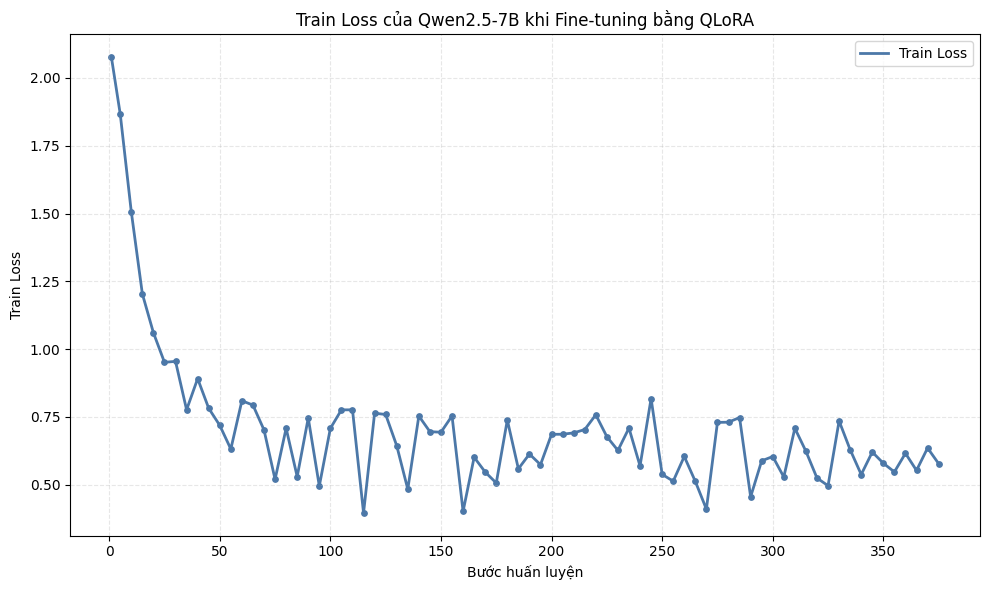

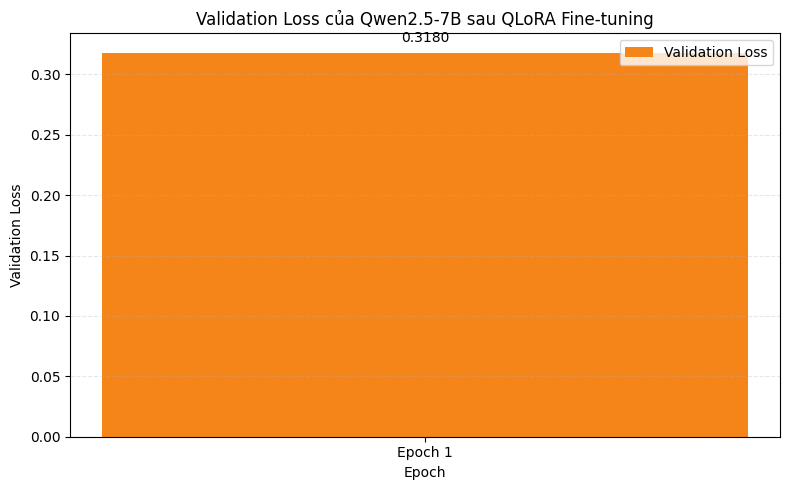


===== ĐÃ LƯU BIỂU ĐỒ =====
Train Loss: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures/04_train_loss_curve.png
Validation Loss: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures/05_validation_loss_curve.png
Số điểm Train Loss: 76
Validation Loss cuối: 0.317962


In [ ]:
import matplotlib.pyplot as plt


# ============================================================
# 1. LẤY LỊCH SỬ HUẤN LUYỆN
# ============================================================

log_history = trainer.state.log_history

train_logs = [
    log
    for log in log_history
    if (
        "loss" in log
        and "eval_loss" not in log
        and "step" in log
    )
]

validation_logs = [
    log
    for log in log_history
    if "eval_loss" in log
]


# ============================================================
# 2. KIỂM TRA TRAIN LOSS
# ============================================================

if not train_logs:
    raise ValueError(
        "Không tìm thấy lịch sử Train Loss "
        "trong checkpoint."
    )


# ============================================================
# 3. TỰ TÍNH VALIDATION LOSS NẾU CHƯA CÓ
# ============================================================

if not validation_logs:
    print(
        "Checkpoint chưa có Validation Loss."
    )
    print(
        "Đang đánh giá mô hình trên tập Validation..."
    )

    validation_result = trainer.evaluate()

    print("\n===== KẾT QUẢ VALIDATION =====")
    print(
        "Validation Loss:",
        validation_result.get(
            "eval_loss"
        ),
    )

    print(
        "Thời gian đánh giá:",
        round(
            validation_result.get(
                "eval_runtime",
                0
            ) / 60,
            2,
        ),
        "phút",
    )

    # Đọc lại lịch sử sau khi đánh giá
    log_history = trainer.state.log_history

    validation_logs = [
        log
        for log in log_history
        if "eval_loss" in log
    ]


# Kiểm tra lại sau khi evaluate
if not validation_logs:
    raise ValueError(
        "Không thể tính được Validation Loss."
    )


# ============================================================
# 4. CHUẨN BỊ THƯ MỤC LƯU BIỂU ĐỒ
# ============================================================

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 5. VẼ BIỂU ĐỒ TRAIN LOSS
# ============================================================

train_steps = [
    log["step"]
    for log in train_logs
]

train_losses = [
    log["loss"]
    for log in train_logs
]


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    train_steps,
    train_losses,
    color="#4C78A8",
    linewidth=2,
    label="Train Loss",
)

plt.scatter(
    train_steps,
    train_losses,
    color="#4C78A8",
    s=15,
)

plt.title(
    "Train Loss của Qwen2.5-7B "
    "khi Fine-tuning bằng QLoRA"
)

plt.xlabel(
    "Bước huấn luyện"
)

plt.ylabel(
    "Train Loss"
)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.legend()
plt.tight_layout()


TRAIN_LOSS_CHART_PATH = (
    FIGURES_DIR
    / "04_train_loss_curve.png"
)

plt.savefig(
    TRAIN_LOSS_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 6. VẼ BIỂU ĐỒ VALIDATION LOSS
# ============================================================

validation_epochs = [
    log.get(
        "epoch",
        index + 1,
    )
    for index, log in enumerate(
        validation_logs
    )
]

validation_losses = [
    log["eval_loss"]
    for log in validation_logs
]


plt.figure(
    figsize=(8, 5)
)

if len(validation_losses) == 1:
    # Chỉ có một epoch nên dùng biểu đồ cột
    bars = plt.bar(
        ["Epoch 1"],
        validation_losses,
        color="#F58518",
        width=0.5,
        label="Validation Loss",
    )

    label_offset = max(
        validation_losses[0] * 0.02,
        0.001,
    )

    plt.text(
        bars[0].get_x()
        + bars[0].get_width() / 2,
        validation_losses[0]
        + label_offset,
        f"{validation_losses[0]:.4f}",
        ha="center",
        va="bottom",
    )

else:
    # Nếu có nhiều epoch thì dùng biểu đồ đường
    plt.plot(
        validation_epochs,
        validation_losses,
        marker="o",
        color="#F58518",
        linewidth=2,
        label="Validation Loss",
    )


plt.title(
    "Validation Loss của Qwen2.5-7B "
    "sau QLoRA Fine-tuning"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Loss"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

plt.legend()
plt.tight_layout()


VALIDATION_LOSS_CHART_PATH = (
    FIGURES_DIR
    / "05_validation_loss_curve.png"
)

plt.savefig(
    VALIDATION_LOSS_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 7. HIỂN THỊ KẾT QUẢ
# ============================================================

print("\n===== ĐÃ LƯU BIỂU ĐỒ =====")

print(
    "Train Loss:",
    TRAIN_LOSS_CHART_PATH,
)

print(
    "Validation Loss:",
    VALIDATION_LOSS_CHART_PATH,
)

print(
    "Số điểm Train Loss:",
    len(train_losses),
)

print(
    "Validation Loss cuối:",
    round(
        validation_losses[-1],
        6,
    ),
)

12B train loss , val loss


Cột Train dùng để đánh giá: ['id', 'prompt', 'completion', 'input_ids', 'completion_mask']
Cột Validation dùng để đánh giá: ['id', 'prompt', 'completion', 'input_ids', 'completion_mask']
Số mẫu Train: 3000
Số mẫu Validation: 1000

Đang tính Final Train Loss...


Final Train Loss: 0.273811
Thời gian đánh giá Train: 111.49 phút

Đang tính Final Validation Loss...
Final Validation Loss: 0.317962
Thời gian đánh giá Validation: 37.07 phút


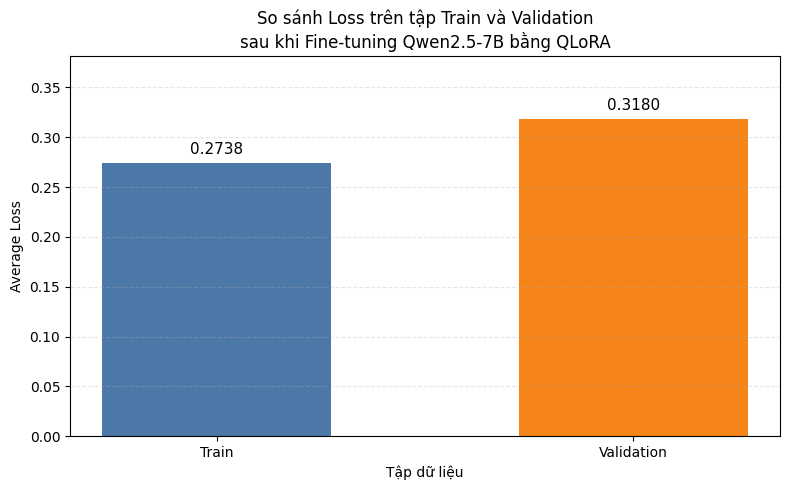

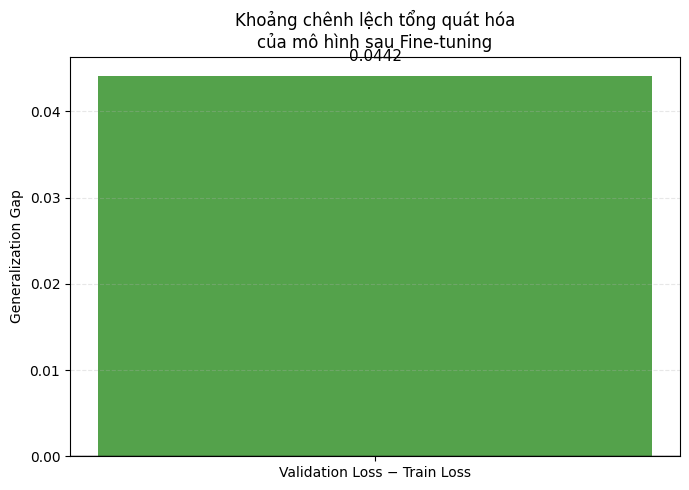


===== KẾT QUẢ CUỐI =====
Final Train Loss      : 0.273811
Final Validation Loss : 0.317962
Generalization Gap    : 0.044151

===== FILE ĐÃ LƯU =====
Biểu đồ Train/Validation: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures/06_final_train_validation_loss.png
Biểu đồ Generalization Gap: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures/07_generalization_gap.png
Số liệu JSON: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/evaluation/train_validation_loss_comparison.json


In [18]:
# ============================================================
# CELL 12B – ĐÁNH GIÁ FINAL TRAIN/VALIDATION LOSS
# VÀ VẼ HAI BIỂU ĐỒ
# ============================================================

import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch


# ============================================================
# 1. KIỂM TRA CÁC BIẾN CẦN THIẾT
# ============================================================

required_variables = [
    "trainer",
    "train_dataset",
    "validation_dataset",
    "FIGURES_DIR",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Thiếu các biến: "
        + ", ".join(missing_variables)
        + ". Hãy chạy lại các cell nạp dữ liệu, mô hình, "
          "QLoRA Adapter và khởi tạo trainer."
    )


FIGURES_DIR = Path(FIGURES_DIR)
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Thư mục lưu kết quả dạng JSON
if "EVALUATION_DIR" in globals():
    LOSS_RESULT_DIR = Path(EVALUATION_DIR)
elif "OUTPUT_DIR" in globals():
    LOSS_RESULT_DIR = Path(OUTPUT_DIR) / "evaluation"
else:
    LOSS_RESULT_DIR = FIGURES_DIR.parent / "evaluation"

LOSS_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. ĐƯA MÔ HÌNH VỀ CHẾ ĐỘ ĐÁNH GIÁ
# ============================================================

trainer.model.eval()

if hasattr(trainer.model.config, "use_cache"):
    trainer.model.config.use_cache = True

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 3. TÍNH LOSS TRÊN TOÀN BỘ TẬP TRAIN
# ============================================================

print("Đang tính Final Train Loss...")

train_evaluation = trainer.evaluate(
    eval_dataset=train_dataset,
    metric_key_prefix="train_final",
)

final_train_loss = float(
    train_evaluation["train_final_loss"]
)

print(
    "Final Train Loss:",
    round(final_train_loss, 6),
)


# ============================================================
# 4. TÍNH LOSS TRÊN TOÀN BỘ TẬP VALIDATION
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nĐang tính Final Validation Loss...")

validation_evaluation = trainer.evaluate(
    eval_dataset=validation_dataset,
    metric_key_prefix="validation_final",
)

final_validation_loss = float(
    validation_evaluation[
        "validation_final_loss"
    ]
)

print(
    "Final Validation Loss:",
    round(final_validation_loss, 6),
)


# ============================================================
# 5. TÍNH KHOẢNG CHÊNH LỆCH
# ============================================================

generalization_gap = (
    final_validation_loss
    - final_train_loss
)

loss_results = {
    "final_train_loss": final_train_loss,
    "final_validation_loss": (
        final_validation_loss
    ),
    "generalization_gap": (
        generalization_gap
    ),
    "train_examples": len(train_dataset),
    "validation_examples": (
        len(validation_dataset)
    ),
}

LOSS_RESULT_PATH = (
    LOSS_RESULT_DIR
    / "train_validation_loss_comparison.json"
)

with LOSS_RESULT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        loss_results,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ============================================================
# 6. BIỂU ĐỒ 1:
# SO SÁNH FINAL TRAIN LOSS VÀ VALIDATION LOSS
# ============================================================

labels = [
    "Train",
    "Validation",
]

loss_values = [
    final_train_loss,
    final_validation_loss,
]

colors = [
    "#4C78A8",
    "#F58518",
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    loss_values,
    color=colors,
    width=0.55,
)

for bar, value in zip(
    bars,
    loss_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height()
        + max(loss_values) * 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.title(
    "So sánh Loss trên tập Train và Validation\n"
    "sau khi Fine-tuning Qwen2.5-7B bằng QLoRA"
)

plt.xlabel("Tập dữ liệu")
plt.ylabel("Average Loss")

plt.ylim(
    0,
    max(loss_values) * 1.20,
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()

TRAIN_VALIDATION_CHART_PATH = (
    FIGURES_DIR
    / "06_final_train_validation_loss.png"
)

plt.savefig(
    TRAIN_VALIDATION_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 7. BIỂU ĐỒ 2:
# KHOẢNG CHÊNH LỆCH TỔNG QUÁT HÓA
# ============================================================

plt.figure(figsize=(7, 5))

gap_color = (
    "#54A24B"
    if generalization_gap >= 0
    else "#E45756"
)

bar = plt.bar(
    ["Validation Loss − Train Loss"],
    [generalization_gap],
    color=gap_color,
    width=0.5,
)

plt.axhline(
    y=0,
    color="black",
    linewidth=1,
)

plt.text(
    bar[0].get_x()
    + bar[0].get_width() / 2,
    generalization_gap,
    f"{generalization_gap:.4f}",
    ha="center",
    va=(
        "bottom"
        if generalization_gap >= 0
        else "top"
    ),
    fontsize=11,
)

plt.title(
    "Khoảng chênh lệch tổng quát hóa\n"
    "của mô hình sau Fine-tuning"
)

plt.ylabel("Generalization Gap")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()

GENERALIZATION_GAP_CHART_PATH = (
    FIGURES_DIR
    / "07_generalization_gap.png"
)

plt.savefig(
    GENERALIZATION_GAP_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 8. HIỂN THỊ KẾT QUẢ
# ============================================================

print("\n===== KẾT QUẢ CUỐI =====")
print(
    f"Final Train Loss      : "
    f"{final_train_loss:.6f}"
)
print(
    f"Final Validation Loss : "
    f"{final_validation_loss:.6f}"
)
print(
    f"Generalization Gap    : "
    f"{generalization_gap:.6f}"
)

print("\n===== FILE ĐÃ LƯU =====")
print(
    "Biểu đồ Train/Validation:",
    TRAIN_VALIDATION_CHART_PATH,
)
print(
    "Biểu đồ Generalization Gap:",
    GENERALIZATION_GAP_CHART_PATH,
)
print(
    "Số liệu JSON:",
    LOSS_RESULT_PATH,
)

12C line

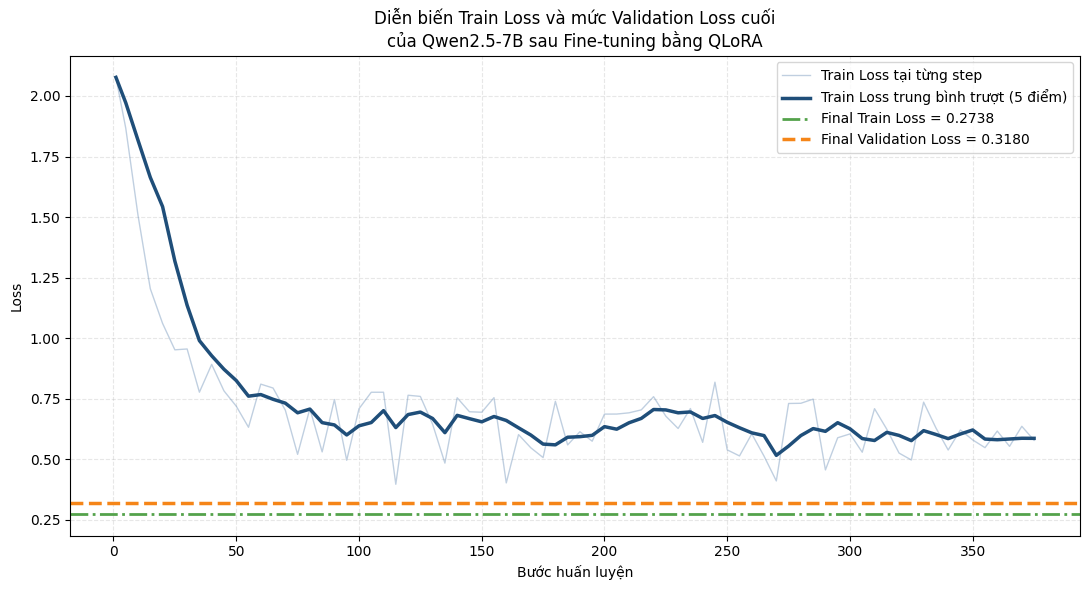

Đã lưu biểu đồ line tại:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/figures/08_train_validation_loss_line.png

Final Train Loss: 0.273811
Final Validation Loss: 0.317962


In [19]:
# ============================================================
# CELL 12C – BIỂU ĐỒ LINE TRAIN/VALIDATION LOSS
# KHÔNG ĐÁNH GIÁ LẠI MÔ HÌNH
# ============================================================

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. LẤY LỊCH SỬ TRAIN LOSS
# ============================================================

log_history = trainer.state.log_history

train_logs = [
    log
    for log in log_history
    if (
        "loss" in log
        and "eval_loss" not in log
        and "step" in log
    )
]

if not train_logs:
    raise ValueError(
        "Không tìm thấy lịch sử Train Loss."
    )


train_steps = [
    int(log["step"])
    for log in train_logs
]

train_losses = [
    float(log["loss"])
    for log in train_logs
]


# ============================================================
# 2. LẤY FINAL TRAIN/VALIDATION LOSS
# ============================================================

if (
    "final_train_loss" not in globals()
    or "final_validation_loss" not in globals()
):
    if "LOSS_RESULT_PATH" in globals():
        result_path = Path(
            LOSS_RESULT_PATH
        )
    elif "EVALUATION_DIR" in globals():
        result_path = (
            Path(EVALUATION_DIR)
            / "train_validation_loss_comparison.json"
        )
    elif "OUTPUT_DIR" in globals():
        result_path = (
            Path(OUTPUT_DIR)
            / "evaluation"
            / "train_validation_loss_comparison.json"
        )
    else:
        result_path = (
            Path(FIGURES_DIR).parent
            / "evaluation"
            / "train_validation_loss_comparison.json"
        )

    if not result_path.exists():
        raise FileNotFoundError(
            "Không tìm thấy file kết quả Cell 12B: "
            f"{result_path}"
        )

    with result_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        loss_results = json.load(file)

    final_train_loss = float(
        loss_results["final_train_loss"]
    )

    final_validation_loss = float(
        loss_results[
            "final_validation_loss"
        ]
    )


# ============================================================
# 3. TÍNH ĐƯỜNG TRAIN LOSS TRUNG BÌNH TRƯỢT
# ============================================================

# Làm mượt đường Train Loss để dễ quan sát xu hướng
smooth_window = min(
    5,
    len(train_losses),
)

smoothed_train_losses = (
    pd.Series(train_losses)
    .rolling(
        window=smooth_window,
        min_periods=1,
    )
    .mean()
    .tolist()
)


# ============================================================
# 4. VẼ BIỂU ĐỒ LINE
# ============================================================

FIGURES_DIR = Path(FIGURES_DIR)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


plt.figure(
    figsize=(11, 6)
)


# Train Loss gốc
plt.plot(
    train_steps,
    train_losses,
    color="#4C78A8",
    linewidth=1,
    alpha=0.35,
    label="Train Loss tại từng step",
)


# Train Loss đã làm mượt
plt.plot(
    train_steps,
    smoothed_train_losses,
    color="#1F4E79",
    linewidth=2.5,
    label=(
        f"Train Loss trung bình trượt "
        f"({smooth_window} điểm)"
    ),
)


# Final Train Loss
plt.axhline(
    y=final_train_loss,
    color="#54A24B",
    linewidth=2,
    linestyle="-.",
    label=(
        "Final Train Loss "
        f"= {final_train_loss:.4f}"
    ),
)


# Final Validation Loss
plt.axhline(
    y=final_validation_loss,
    color="#F58518",
    linewidth=2.5,
    linestyle="--",
    label=(
        "Final Validation Loss "
        f"= {final_validation_loss:.4f}"
    ),
)


plt.title(
    "Diễn biến Train Loss và mức Validation Loss cuối\n"
    "của Qwen2.5-7B sau Fine-tuning bằng QLoRA"
)

plt.xlabel(
    "Bước huấn luyện"
)

plt.ylabel(
    "Loss"
)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.legend()

plt.tight_layout()


LINE_CHART_PATH = (
    FIGURES_DIR
    / "08_train_validation_loss_line.png"
)


plt.savefig(
    LINE_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


print(
    "Đã lưu biểu đồ line tại:"
)

print(
    LINE_CHART_PATH
)

print(
    "\nFinal Train Loss:",
    round(
        final_train_loss,
        6,
    ),
)

print(
    "Final Validation Loss:",
    round(
        final_validation_loss,
        6,
    ),
)

13. Thử mô hình Fine-tuning

In [20]:
# ============================================================
# CELL 13 - KIỂM TRA THỬ MÔ HÌNH SAU FINE-TUNING
# ============================================================

import torch

model.eval()
model.config.use_cache = True


# ------------------------------------------------------------
# 1. Lấy một mẫu Validation
# Không sử dụng Test để tránh xem trước dữ liệu đánh giá
# ------------------------------------------------------------

example = raw_datasets["validation"][0]

all_messages = example["messages"]

# Tin nhắn cuối đã được Cell 6 xác nhận là assistant
reference_answer = all_messages[-1]["content"]

# System và User được dùng làm đầu vào
generation_messages = all_messages[:-1]

# Lấy nội dung câu hỏi để hiển thị
question_text = next(
    message["content"]
    for message in reversed(generation_messages)
    if message["role"] == "user"
)


# ------------------------------------------------------------
# 2. Chuyển hội thoại thành token
# ------------------------------------------------------------

inputs = tokenizer.apply_chat_template(
    generation_messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)


# ------------------------------------------------------------
# 3. Sinh câu trả lời
# ------------------------------------------------------------

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )


# Chỉ lấy token do mô hình mới sinh ra
new_tokens = generated_ids[
    0,
    inputs["input_ids"].shape[1]:
]


prediction = tokenizer.decode(
    new_tokens,
    skip_special_tokens=True,
).strip()


# ------------------------------------------------------------
# 4. Hiển thị kết quả
# ------------------------------------------------------------

print("===== CÂU HỎI =====")
print(question_text)

print("\n===== ĐÁP ÁN CHUẨN =====")
print(reference_answer)

print("\n===== MÔ HÌNH FINE-TUNING TRẢ LỜI =====")
print(prediction)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


===== CÂU HỎI =====
Đối với “Gia hạn Giấy phép tiến hành công việc bức xạ - sử dụng thiết bị phát tia X trong chụp ảnh phóng xạ công nghiệp, thiết bị phát nơtron, electron và hạt mang điện khác; thay đổi quy mô và phạm vi hoạt động của cơ sở bức xạ; chấm dứt hoạt động của cơ sở bức xạ” (mã 1.115137), Hãy cho tôi mã hồ sơ mà tôi đã nộp.

===== ĐÁP ÁN CHUẨN =====
Bạn chưa cung cấp mã hồ sơ; tài liệu mô tả thủ tục không chứa mã hồ sơ cá nhân của bạn.

===== MÔ HÌNH FINE-TUNING TRẢ LỜI =====
Bạn chưa cung cấp mã hồ sơ; tài liệu mô tả thủ tục không chứa mã hồ sơ cá nhân của bạn.


14. Nén QLoRA adapter

In [21]:
import shutil

from pathlib import Path


ZIP_BASE = (
    OUTPUT_ROOT
    / "qwen2_5_7b_qlora_adapter"
)

zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=str(ADAPTER_DIR),
)

zip_size_mb = (
    Path(zip_path).stat().st_size
    / 1024**2
)

print("Đã tạo file ZIP:")
print(zip_path)

print(
    "Kích thước:",
    round(zip_size_mb, 2),
    "MB",
)

Đã tạo file ZIP:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/qwen2_5_7b_qlora_adapter.zip
Kích thước: 75.59 MB


15. cài thư viện đánh giá

In [22]:
!pip install -q \
    nltk==3.9.1 \
    rouge-score==0.1.2 \
    bert-score==0.3.13

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


16. Khai báo nơi lưu kết quả đánh giá

In [23]:
EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PREDICTIONS_PATH = (
    EVALUATION_DIR
    / "finetuned_predictions.jsonl"
)

METRICS_PATH = (
    EVALUATION_DIR
    / "finetuned_case_metrics.csv"
)

SUMMARY_PATH = (
    EVALUATION_DIR
    / "finetuned_summary.json"
)

SUMMARY_TABLE_PATH = (
    EVALUATION_DIR
    / "finetuned_summary_table.csv"
)


if not TEST_FILE.exists():
    raise FileNotFoundError(
        f"Không tìm thấy tập test: {TEST_FILE}"
    )


adapter_weight_file = (
    ADAPTER_DIR
    / "adapter_model.safetensors"
)

if not adapter_weight_file.exists():
    raise FileNotFoundError(
        "Không tìm thấy adapter_model.safetensors tại:\n"
        f"{ADAPTER_DIR}"
    )


print("===== ĐƯỜNG DẪN ĐÁNH GIÁ =====")
print("Test:", TEST_FILE)
print("Adapter:", ADAPTER_DIR)
print("Predictions:", PREDICTIONS_PATH)
print("Metrics:", METRICS_PATH)
print("Summary:", SUMMARY_PATH)

===== ĐƯỜNG DẪN ĐÁNH GIÁ =====
Test: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/data/fintuning/test_sft.jsonl
Adapter: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/adapter
Predictions: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/evaluation/finetuned_predictions.jsonl
Metrics: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/evaluation/finetuned_case_metrics.csv
Summary: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qa_test/tthc_test_case_v1/results/qwen2_5_7b_qlora/evaluation/finetuned_summary.json


17. Chuẩn bị mô hình và tập test

In [24]:
import torch

from datasets import load_dataset


test_dataset = load_dataset(
    "json",
    data_files=str(TEST_FILE),
    split="train",
)

required_test_columns = {
    "id",
    "messages",
}

missing_test_columns = (
    required_test_columns
    - set(test_dataset.column_names)
)

if missing_test_columns:
    raise ValueError(
        "Tập Test thiếu các cột: "
        f"{sorted(missing_test_columns)}"
    )


print("Số mẫu Test:", len(test_dataset))


model_available = (
    "model" in globals()
    and model is not None
)

tokenizer_available = (
    "tokenizer" in globals()
    and tokenizer is not None
)


if model_available and tokenizer_available:
    print(
        "Sử dụng mô hình Fine-tuning "
        "đang có trong GPU."
    )

else:
    print(
        "Đang nạp lại Base model "
        "và QLoRA Adapter..."
    )

    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        BitsAndBytesConfig,
    )

    from peft import PeftModel

    USE_BF16 = (
        torch.cuda.is_bf16_supported()
    )

    COMPUTE_DTYPE = (
        torch.bfloat16
        if USE_BF16
        else torch.float16
    )

    quantization_config = (
        BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=(
                COMPUTE_DTYPE
            ),
        )
    )

    tokenizer = (
        AutoTokenizer.from_pretrained(
            MODEL_NAME,
            revision=MODEL_REVISION,
            use_fast=True,
        )
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = (
            tokenizer.eos_token
        )

    tokenizer.padding_side = "right"

    base_model = (
        AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            revision=MODEL_REVISION,
            quantization_config=(
                quantization_config
            ),
            device_map={"": 0},
            torch_dtype=COMPUTE_DTYPE,
            low_cpu_mem_usage=True,
        )
    )

    model = PeftModel.from_pretrained(
        base_model,
        str(ADAPTER_DIR),
    )


model.eval()
model.config.use_cache = True

print("Mô hình đã sẵn sàng.")
print(
    "Thiết bị:",
    next(model.parameters()).device,
)

Số mẫu Test: 1000
Sử dụng mô hình Fine-tuning đang có trong GPU.
Mô hình đã sẵn sàng.
Thiết bị: cuda:0


18. Sinh câu trả lời trên toàn bộ test_pilot

In [ ]:
import json
import time

import torch

from tqdm.auto import tqdm


MAX_NEW_TOKENS = 512

# False: tiếp tục từ kết quả đã chạy.
# True: xóa kết quả cũ và chạy lại toàn bộ.
RESET_PREDICTIONS = False


if (
    RESET_PREDICTIONS
    and PREDICTIONS_PATH.exists()
):
    PREDICTIONS_PATH.unlink()
    print("Đã xóa kết quả dự đoán cũ.")


def read_jsonl(file_path):
    if not file_path.exists():
        return []

    records = []

    with file_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        for line in file:
            if line.strip():
                records.append(
                    json.loads(line)
                )

    return records


existing_records = read_jsonl(
    PREDICTIONS_PATH
)

completed_ids = {
    record["id"]
    for record in existing_records
}

pending_examples = [
    example
    for example in test_dataset
    if example["id"] not in completed_ids
]


print(
    "Đã hoàn thành trước đó:",
    len(completed_ids),
)

print(
    "Số mẫu cần chạy:",
    len(pending_examples),
)


with PREDICTIONS_PATH.open(
    "a",
    encoding="utf-8",
) as output_file:

    for example in tqdm(
        pending_examples,
        desc="Fine-tuning inference",
    ):
        all_messages = example["messages"]

        # Đáp án chuẩn là assistant cuối cùng
        reference_answer = (
            all_messages[-1]["content"]
            .strip()
        )

        # Prompt là toàn bộ hội thoại trước đáp án cuối
        generation_messages = (
            all_messages[:-1]
        )

        # Câu hỏi cuối cùng của người dùng
        question_text = next(
            message["content"].strip()
            for message in reversed(
                generation_messages
            )
            if message["role"] == "user"
        )

        inputs = tokenizer.apply_chat_template(
            generation_messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        ).to(model.device)

        input_token_count = int(
            inputs["input_ids"].shape[1]
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        with torch.inference_mode():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=(
                    MAX_NEW_TOKENS
                ),
                do_sample=False,
                repetition_penalty=1.05,
                pad_token_id=(
                    tokenizer.pad_token_id
                ),
                eos_token_id=(
                    tokenizer.eos_token_id
                ),
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        latency_seconds = (
            time.perf_counter()
            - start_time
        )

        new_token_ids = generated_ids[
            0,
            input_token_count:
        ]

        prediction_text = (
            tokenizer.decode(
                new_token_ids,
                skip_special_tokens=True,
            )
            .strip()
        )

        output_token_count = int(
            len(new_token_ids)
        )

        record = {
            "id": example["id"],
            "model": (
                "Qwen2.5-7B-Instruct "
                "+ QLoRA"
            ),
            "pipeline": (
                "Fine-tuning without RAG"
            ),
            "question": question_text,
            "ground_truth": (
                reference_answer
            ),
            "reference_answer": (
                reference_answer
            ),
            "prediction": (
                prediction_text
            ),
            "conversation_turns": (
                len(all_messages) // 2
            ),
            "question_type": None,
            "difficulty": None,
            "answerability": None,
            "latency_s": (
                latency_seconds
            ),
            "input_tokens": (
                input_token_count
            ),
            "output_tokens": (
                output_token_count
            ),
        }

        output_file.write(
            json.dumps(
                record,
                ensure_ascii=False,
            )
            + "\n"
        )

        output_file.flush()

        del inputs
        del generated_ids
        del new_token_ids


prediction_records = read_jsonl(
    PREDICTIONS_PATH
)

prediction_ids = {
    record["id"]
    for record in prediction_records
}

test_ids = {
    example["id"]
    for example in test_dataset
}


print(
    "\nĐã hoàn thành:",
    len(prediction_ids & test_ids),
    "/",
    len(test_dataset),
)

print("Kết quả lưu tại:")
print(PREDICTIONS_PATH)

Đã hoàn thành trước đó: 0
Số mẫu cần chạy: 1000


Fine-tuning inference:   0%|          | 0/1000 [00:00<?, ?it/s]

19. Tính Accuracy, BLEU và ROUGE

In [ ]:
import json
import re
import unicodedata

import pandas as pd

from nltk.translate.bleu_score import (
    SmoothingFunction,
    sentence_bleu,
)

from rouge_score import rouge_scorer


def normalize_answer(text):
    if text is None:
        return ""

    text = unicodedata.normalize(
        "NFC",
        str(text),
    )

    text = text.lower().strip()

    text = re.sub(
        r'[“”"`]',
        "",
        text,
    )

    text = re.sub(
        r"[.,;:!?()\[\]{}]",
        " ",
        text,
    )

    text = re.sub(
        r"\s+",
        " ",
        text,
    )

    return text.strip()


def exact_match(
    prediction,
    reference,
):
    return int(
        str(prediction).strip()
        == str(reference).strip()
    )


def normalized_accuracy(
    prediction,
    reference,
):
    return int(
        normalize_answer(prediction)
        == normalize_answer(reference)
    )


smooth = (
    SmoothingFunction().method1
)


def bleu_score(
    prediction,
    reference,
):
    prediction_tokens = (
        normalize_answer(
            prediction
        ).split()
    )

    reference_tokens = (
        normalize_answer(
            reference
        ).split()
    )

    if (
        not prediction_tokens
        or not reference_tokens
    ):
        return 0.0

    return float(
        sentence_bleu(
            [reference_tokens],
            prediction_tokens,
            weights=(
                0.25,
                0.25,
                0.25,
                0.25,
            ),
            smoothing_function=smooth,
        )
    )


rouge = rouge_scorer.RougeScorer(
    [
        "rouge1",
        "rouge2",
        "rougeL",
    ],
    use_stemmer=False,
)


def rouge_scores(
    prediction,
    reference,
):
    result = rouge.score(
        normalize_answer(reference),
        normalize_answer(prediction),
    )

    return {
        "rouge1_f1": float(
            result["rouge1"].fmeasure
        ),
        "rouge2_f1": float(
            result["rouge2"].fmeasure
        ),
        "rougeL_f1": float(
            result["rougeL"].fmeasure
        ),
    }


prediction_records = read_jsonl(
    PREDICTIONS_PATH
)

if not prediction_records:
    raise RuntimeError(
        "Chưa có kết quả dự đoán."
    )


metric_records = []

for record in prediction_records:
    prediction = record.get(
        "prediction",
        "",
    )

    reference = record.get(
        "ground_truth",
        record.get(
            "reference_answer",
            "",
        ),
    )

    rouge_result = rouge_scores(
        prediction,
        reference,
    )

    metric_records.append({
        **record,

        "exact_match_raw": exact_match(
            prediction,
            reference,
        ),

        "accuracy_normalized": (
            normalized_accuracy(
                prediction,
                reference,
            )
        ),

        "bleu4": bleu_score(
            prediction,
            reference,
        ),

        **rouge_result,
    })


metrics_df = pd.DataFrame(
    metric_records
)


display(
    metrics_df[
        [
            "id",
            "conversation_turns",
            "exact_match_raw",
            "accuracy_normalized",
            "bleu4",
            "rouge1_f1",
            "rouge2_f1",
            "rougeL_f1",
            "latency_s",
        ]
    ].head(10)
)

print(
    "Đã tính Accuracy, BLEU và ROUGE "
    f"cho {len(metrics_df)} mẫu."
)

,id,question_type,exact_match_raw,accuracy_normalized,bleu4,rouge1_f1,rouge2_f1,rougeL_f1,latency_s
0,qa_000013,metadata_identity,0,0,0.436684,0.769231,0.666667,0.769231,8.495365
1,qa_000014,procedure_step,0,0,0.001850,0.026954,0.010840,0.026954,50.147225
2,qa_000015,submission_deadline_fee,0,0,0.872972,0.904255,0.881720,0.904255,11.492687
3,qa_000016,required_documents,0,0,0.049320,0.149682,0.115016,0.133758,74.813328
4,qa_000017,metadata_identity,0,0,0.366193,0.689655,0.518519,0.689655,4.476473
5,qa_000018,procedure_step,0,0,0.019245,0.374012,0.267370,0.251097,24.398004
6,qa_000019,submission_deadline_fee,0,0,0.000475,0.251553,0.130841,0.217391,11.746205
7,qa_000020,required_documents,0,0,0.068450,0.480000,0.171821,0.285714,66.350581
8,qa_000045,metadata_identity,0,0,0.366193,0.727273,0.516129,0.666667,4.039897
9,qa_000046,procedure_step,0,0,0.056364,0.596154,0.223301,0.326923,8.272531


Đã tính Accuracy, BLEU và ROUGE.


20. Tính BERTScore

giải phóng GPU

In [ ]:
import gc
import torch

if "trainer" in globals():
    del trainer

if "model" in globals():
    del model

if "base_model" in globals():
    del base_model

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory sau khi giải phóng:",
    round(
        torch.cuda.memory_allocated() / 1024**3,
        2
    ),
    "GB"
)

GPU memory sau khi giải phóng: 2.05 GB


Tính BERTScore

In [ ]:
import torch

from bert_score import (
    score as bertscore_score,
)


BERTSCORE_MODEL = (
    "xlm-roberta-large"
)

predictions = (
    metrics_df["prediction"]
    .fillna("")
    .astype(str)
    .tolist()
)

references = (
    metrics_df["ground_truth"]
    .fillna("")
    .astype(str)
    .tolist()
)

bert_device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Thiết bị tính BERTScore:",
    bert_device,
)


bert_precision, bert_recall, bert_f1 = (
    bertscore_score(
        predictions,
        references,
        model_type=BERTSCORE_MODEL,
        lang=None,
        device=bert_device,
        batch_size=4,
        verbose=True,
        rescale_with_baseline=False,
    )
)


metrics_df["bertscore_precision"] = (
    bert_precision
    .cpu()
    .numpy()
)

metrics_df["bertscore_recall"] = (
    bert_recall
    .cpu()
    .numpy()
)

metrics_df["bertscore_f1"] = (
    bert_f1
    .cpu()
    .numpy()
)


print("Đã tính xong BERTScore.")

display(
    metrics_df[
        [
            "id",
            "bertscore_precision",
            "bertscore_recall",
            "bertscore_f1",
        ]
    ].head(10)
)

Thiết bị tính BERTScore: cuda


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/11 [00:00<?, ?it/s]

done in 4.31 seconds, 19.93 sentences/sec
Đã tính xong BERTScore.


,id,bertscore_precision,bertscore_recall,bertscore_f1
0,qa_000013,0.912467,0.906930,0.909690
1,qa_000014,0.455688,0.637565,0.531498
2,qa_000015,0.946937,0.918194,0.932344
3,qa_000016,0.556575,0.753968,0.640406
4,qa_000017,0.907215,0.937269,0.921997
5,qa_000018,0.730179,0.699360,0.714437
6,qa_000019,0.671792,0.593777,0.630380
7,qa_000020,0.615054,0.652562,0.633253
8,qa_000045,0.918207,0.926212,0.922192
9,qa_000046,0.698489,0.665669,0.681684


21. Tổng hợp và lưu kết quả cuối cùng

In [ ]:
import json

import pandas as pd


# ============================================================
# LƯU KẾT QUẢ TỪNG CÂU
# ============================================================

metrics_df.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# KẾT QUẢ TỔNG THỂ
# ============================================================

summary = {
    "model": (
        "Qwen/Qwen2.5-7B-Instruct "
        "+ QLoRA"
    ),

    "pipeline": (
        "Fine-tuning without RAG"
    ),

    "adapter_path": str(
        ADAPTER_DIR
    ),

    "test_file": str(
        TEST_FILE
    ),

    "n_cases": int(
        len(metrics_df)
    ),

    "accuracy_exact_match_raw": float(
        metrics_df[
            "exact_match_raw"
        ].mean()
    ),

    "accuracy_normalized": float(
        metrics_df[
            "accuracy_normalized"
        ].mean()
    ),

    "bleu4": float(
        metrics_df[
            "bleu4"
        ].mean()
    ),

    "rouge1_f1": float(
        metrics_df[
            "rouge1_f1"
        ].mean()
    ),

    "rouge2_f1": float(
        metrics_df[
            "rouge2_f1"
        ].mean()
    ),

    "rougeL_f1": float(
        metrics_df[
            "rougeL_f1"
        ].mean()
    ),

    "bertscore_precision": float(
        metrics_df[
            "bertscore_precision"
        ].mean()
    ),

    "bertscore_recall": float(
        metrics_df[
            "bertscore_recall"
        ].mean()
    ),

    "bertscore_f1": float(
        metrics_df[
            "bertscore_f1"
        ].mean()
    ),

    "mean_latency_s": float(
        metrics_df[
            "latency_s"
        ].mean()
    ),

    "p50_latency_s": float(
        metrics_df[
            "latency_s"
        ].median()
    ),

    "p95_latency_s": float(
        metrics_df[
            "latency_s"
        ].quantile(0.95)
    ),

    "mean_input_tokens": float(
        metrics_df[
            "input_tokens"
        ].mean()
    ),

    "mean_output_tokens": float(
        metrics_df[
            "output_tokens"
        ].mean()
    ),
}


# ============================================================
# KẾT QUẢ THEO SỐ LƯỢT HỘI THOẠI
# ============================================================

turn_report = (
    metrics_df
    .groupby(
        "conversation_turns"
    )[
        [
            "accuracy_normalized",
            "bleu4",
            "rougeL_f1",
            "bertscore_f1",
            "latency_s",
        ]
    ]
    .mean()
    .sort_index()
)

summary["by_conversation_turns"] = (
    turn_report.to_dict(
        orient="index"
    )
)


with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ============================================================
# BẢNG NGANG DÙNG ĐỂ SO SÁNH
# ============================================================

summary_table = pd.DataFrame([
    {
        "Model": (
            "Qwen2.5-7B-Instruct "
            "+ QLoRA"
        ),

        "Test cases": summary[
            "n_cases"
        ],

        "Accuracy": summary[
            "accuracy_normalized"
        ],

        "BLEU-4": summary[
            "bleu4"
        ],

        "ROUGE-1 F1": summary[
            "rouge1_f1"
        ],

        "ROUGE-2 F1": summary[
            "rouge2_f1"
        ],

        "ROUGE-L F1": summary[
            "rougeL_f1"
        ],

        "BERTScore F1": summary[
            "bertscore_f1"
        ],

        "Mean latency (s)": summary[
            "mean_latency_s"
        ],
    }
])


summary_table.to_csv(
    SUMMARY_TABLE_PATH,
    index=False,
    encoding="utf-8-sig",
)


print("===== KẾT QUẢ FINE-TUNING =====")

display(summary_table)

print(
    "\n===== THEO SỐ LƯỢT HỘI THOẠI ====="
)

display(turn_report)


print("\n===== FILE ĐÃ LƯU =====")
print("Predictions:", PREDICTIONS_PATH)
print("Metrics:", METRICS_PATH)
print("Summary:", SUMMARY_PATH)
print("Summary table:", SUMMARY_TABLE_PATH)

===== KẾT QUẢ FINE-TUNING =====
{
  "model": "Qwen/Qwen2.5-7B-Instruct + QLoRA pilot adapter",
  "adapter_path": "/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/adapter",
  "test_file": "/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_split/test_pilot.jsonl",
  "n_cases": 86,
  "accuracy_exact_match_raw": 0.08139534883720931,
  "accuracy_normalized": 0.08139534883720931,
  "bleu4": 0.37290336744015956,
  "rouge1_f1": 0.6201887651116832,
  "rouge2_f1": 0.4913947446313509,
  "rougeL_f1": 0.5477424805045747,
  "bertscore_precision": 0.8113719820976257,
  "bertscore_recall": 0.8079278469085693,
  "bertscore_f1": 0.8072300553321838,
  "mean_latency_s": 24.253999824953425,
  "p50_latency_s": 11.99510636749983,
  "p95_latency_s": 63.48180187224989,
  "mean_input_tokens": 96.34883720930233,
  "mean_output_tokens": 188.45348837209303
}

===== THEO QUESTION TYPE =====


,accuracy_normalized,bleu4,rougeL_f1,bertscore_f1,latency_s
question_type,,,,,
metadata_identity,0.000000,0.434487,0.719936,0.924980,4.304474
multi_hop_metadata_operation,0.000000,0.733241,0.814165,0.905311,14.134562
procedure_step,0.000000,0.081581,0.308197,0.702749,24.713370
required_documents,0.000000,0.088424,0.265750,0.658305,64.176860
submission_deadline_fee,0.111111,0.532759,0.638249,0.840297,14.553840
unanswerable_missing_field,1.000000,1.000000,1.000000,1.000000,3.831824



===== THEO DIFFICULTY =====


,accuracy_normalized,bleu4,rougeL_f1,bertscore_f1,latency_s
difficulty,,,,,
easy,0.000000,0.434487,0.719936,0.924980,4.304474
medium,0.037037,0.234255,0.404065,0.733784,34.481357
hard,0.357143,0.828512,0.880534,0.939128,10.455013



===== FILE ĐÃ LƯU =====
Predictions: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_predictions.jsonl
Metrics: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_metrics.csv
Summary: /content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_summary.json


22. Tạo bảng tổng hợp Fine-tuning

In [ ]:
import json

import pandas as pd

from pathlib import Path
from google.colab import drive


drive.mount(
    "/content/drive",
    force_remount=False,
)


PROJECT_DIR = Path(
    "/content/drive/MyDrive/ViGovBot_KLCN_2026"
)

TEST_CASE_DIR = (
    PROJECT_DIR
    / "data"
    / "qa_test"
    / "tthc_test_case_v1"
)

OUTPUT_ROOT = (
    TEST_CASE_DIR
    / "results"
    / "qwen2_5_7b_qlora"
)

EVALUATION_DIR = (
    OUTPUT_ROOT
    / "evaluation"
)

FIGURES_DIR = (
    OUTPUT_ROOT
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SUMMARY_PATH = (
    EVALUATION_DIR
    / "finetuned_summary.json"
)

SUMMARY_TABLE_PATH = (
    EVALUATION_DIR
    / "finetuned_summary_table.csv"
)


if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy kết quả:\n"
        f"{SUMMARY_PATH}"
    )


with SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    finetuned_summary = json.load(file)


finetuned_summary_table = pd.DataFrame([
    {
        "Model": (
            "Qwen2.5-7B-Instruct "
            "+ QLoRA"
        ),

        "Test cases": finetuned_summary[
            "n_cases"
        ],

        "Accuracy": finetuned_summary[
            "accuracy_normalized"
        ],

        "BLEU-4": finetuned_summary[
            "bleu4"
        ],

        "ROUGE-1 F1": finetuned_summary[
            "rouge1_f1"
        ],

        "ROUGE-2 F1": finetuned_summary[
            "rouge2_f1"
        ],

        "ROUGE-L F1": finetuned_summary[
            "rougeL_f1"
        ],

        "BERTScore F1": finetuned_summary[
            "bertscore_f1"
        ],

        "Mean latency (s)": (
            finetuned_summary[
                "mean_latency_s"
            ]
        ),
    }
])


display(finetuned_summary_table)

print("Đã đọc kết quả tại:")
print(SUMMARY_PATH)

Mounted at /content/drive
Đã tìm thấy kết quả:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_summary.json


,Model,Accuracy,BLEU-4,ROUGE-L F1,BERTScore F1,Mean Latency (s)
0,Qwen2.5-7B-Instruct + QLoRA,0.081395,0.372903,0.547742,0.80723,24.254



Đã lưu bảng tại:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_summary_table.csv


23. Vẽ biểu đồ Fine-tuning

In [ ]:
# # ============================================================
# # CELL 23 - BIỂU ĐỒ CHỈ SỐ FINE-TUNING
# # ============================================================

# import matplotlib.pyplot as plt


# metric_names = [
#     "Accuracy",
#     "BLEU-4",
#     "ROUGE-L F1",
#     "BERTScore F1",
# ]

# metric_values = [
#     finetuned_summary[
#         "accuracy_normalized"
#     ],
#     finetuned_summary[
#         "bleu4"
#     ],
#     finetuned_summary[
#         "rougeL_f1"
#     ],
#     finetuned_summary[
#         "bertscore_f1"
#     ],
# ]


# plt.figure(
#     figsize=(9, 5)
# )

# bars = plt.bar(
#     metric_names,
#     metric_values,
#     color=[
#         "#4C78A8",
#         "#F58518",
#         "#54A24B",
#         "#E45756",
#     ],
# )

# plt.ylim(0, 1)
# plt.ylabel("Score")

# plt.title(
#     "Fine-tuning evaluation — "
#     "Qwen2.5-7B-Instruct + QLoRA"
# )


# # Hiện giá trị trên đầu mỗi cột
# for bar, value in zip(
#     bars,
#     metric_values,
# ):
#     plt.text(
#         bar.get_x()
#         + bar.get_width() / 2,
#         value + 0.02,
#         f"{value:.4f}",
#         ha="center",
#         va="bottom",
#     )


# plt.tight_layout()


# # Lưu biểu đồ
# FINETUNED_CHART_PATH = (
#     EVALUATION_DIR
#     / "finetuned_pilot_metrics_chart.png"
# )

# plt.savefig(
#     FINETUNED_CHART_PATH,
#     dpi=300,
#     bbox_inches="tight",
# )

# plt.show()


# print(
#     "Đã lưu biểu đồ tại:"
# )
# print(FINETUNED_CHART_PATH)

23. biểu đồ

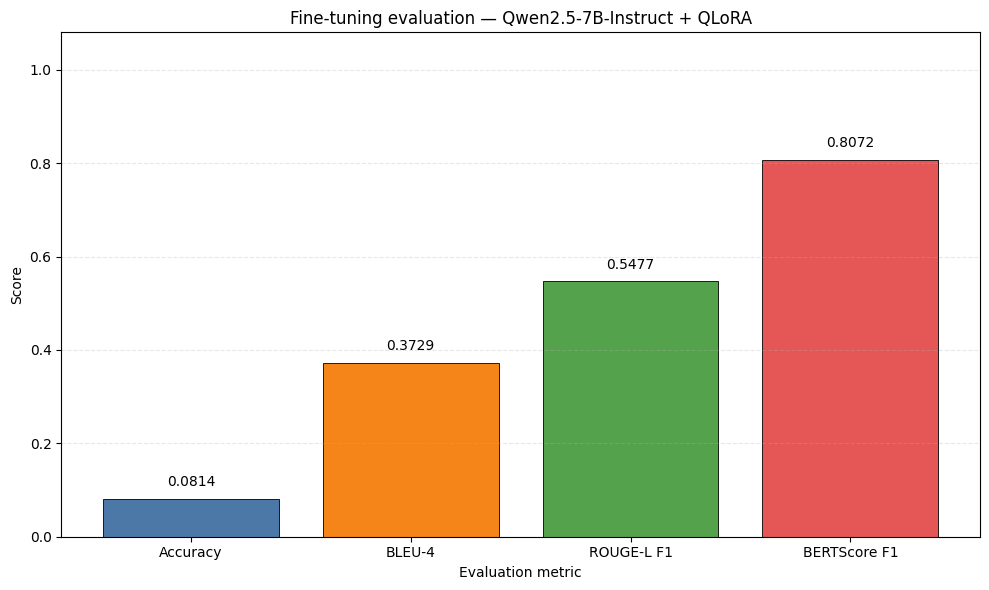

===== KẾT QUẢ TỔNG THỂ QLORA =====
Accuracy: 0.081395
BLEU-4: 0.372903
ROUGE-L F1: 0.547742
BERTScore F1: 0.807230

Mean Latency: 24.254000 giây

Đã lưu biểu đồ tại:
/content/drive/MyDrive/ViGovBot_KLCN_2026/data/qlora_pilot_results/evaluation/finetuned_pilot_metrics_chart.png


In [ ]:
import matplotlib.pyplot as plt


metric_names = [
    "Accuracy",
    "BLEU-4",
    "ROUGE-L F1",
    "BERTScore F1",
]

metric_values = [
    finetuned_summary[
        "accuracy_normalized"
    ],
    finetuned_summary[
        "bleu4"
    ],
    finetuned_summary[
        "rougeL_f1"
    ],
    finetuned_summary[
        "bertscore_f1"
    ],
]


plt.figure(figsize=(10, 6))

bars = plt.bar(
    metric_names,
    metric_values,
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
    ],
    edgecolor="black",
    linewidth=0.6,
)

plt.ylim(0, 1.08)
plt.ylabel("Score")

plt.title(
    "Đánh giá Qwen2.5-7B-Instruct "
    "sau QLoRA Fine-tuning"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)


for bar, value in zip(
    bars,
    metric_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()

FINAL_CHART_PATH = (
    FIGURES_DIR
    / "06_test_evaluation_metrics.png"
)

plt.savefig(
    FINAL_CHART_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("===== KẾT QUẢ QLORA =====")

for name, value in zip(
    metric_names,
    metric_values,
):
    print(f"{name}: {value:.6f}")

print(
    "Mean latency:",
    f"{finetuned_summary['mean_latency_s']:.6f}",
    "giây",
)

print("\nBiểu đồ đã lưu tại:")
print(FINAL_CHART_PATH)